配置：生成 8 个神经元，时长 2000 秒的数据...
采样率: 30000.0 Hz, 训练/测试分割点: 30000000 帧

[Step 1] 正在收集全网波形用于训练 PCA...
PCA 训练集形状: (23891, 1440)
PCA 解释方差比: 0.6856

[Step 2] 正在生成每个神经元的标准指纹...
Unit 0 指纹: 10100000000101000111010010000001
Unit 1 指纹: 11101111100110011100001011010110
Unit 2 指纹: 11011110011110011110101101110010
Unit 3 指纹: 11011101000011001110111101001111
Unit 4 指纹: 11011010111101011110111000101110
Unit 5 指纹: 00101010101100110010001010000010
Unit 6 指纹: 11100010110001101010010010001110
Unit 7 指纹: 11000010011101001001100000100010

[Step 3] 正在进行全对全匹配测试 (Test Phase)...


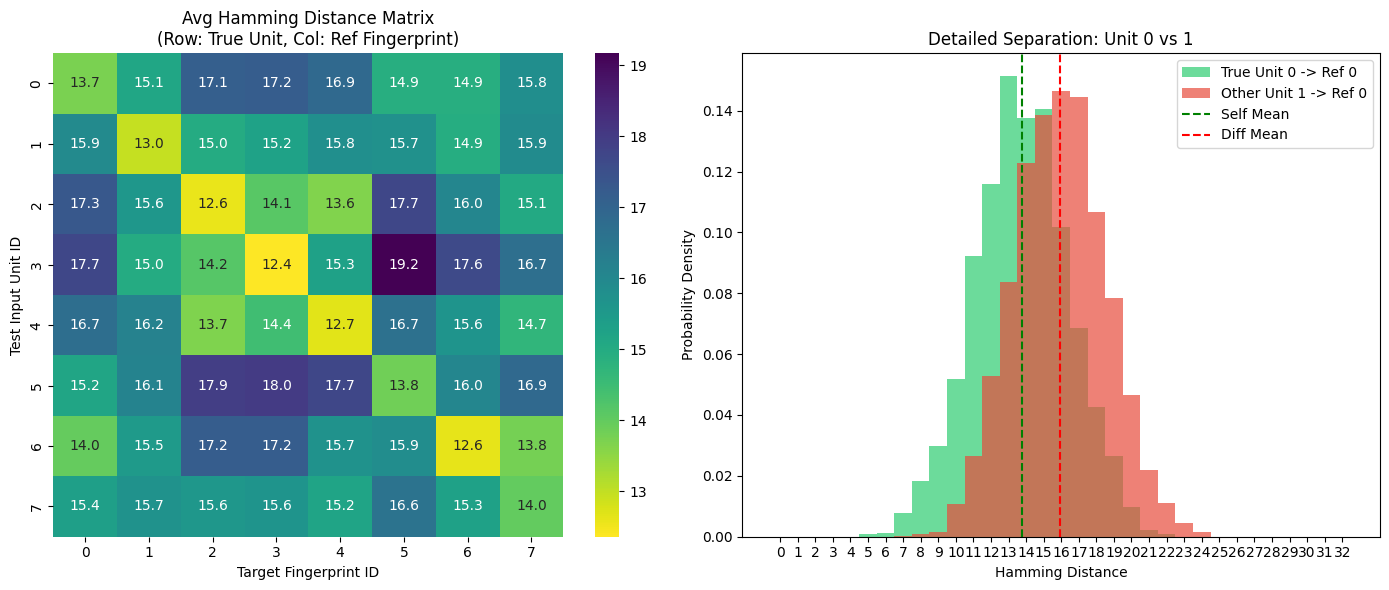


分析完成。


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import spikeinterface.full as si
from sklearn.decomposition import PCA
import seaborn as sns  # 如果没有安装 seaborn，可以注释掉相关的绘图代码，改用 matplotlib
import joblib

# =========================================================
# 1. 参数配置 (Configuration) - 在这里调整 a 和 b
# =========================================================
CONFIG = {
    # --- 核心参数 ---
    "NUM_UNITS": 8,          # [a] 神经元数量
    "DURATION": 2000,         # [b] 数据时长 (秒)
    "NUM_CHANNELS": 32,       # 通道数
    
    # --- 算法参数 ---
    "PCA_COMPONENTS": 32,     # PCA 降维维度
    "TRAIN_RATIO": 0.5,      # 前 50% 做训练，后 50% 做测试
    "WAVEFORM_WINDOW": 1.5,  # 截取波形的总长度 (ms)
    "PRE_WINDOW": 0.5,       # 峰值前长度 (ms)
    
    # --- 采样限制 (防止内存溢出) ---
    "MAX_PCA_SAMPLES": 50000, # 用于训练 PCA 的最大波形数
    "MAX_REF_SAMPLES": 50000,   # 用于计算标准指纹的最大波形数
    "MAX_TEST_SAMPLES": 50000,  # 每个神经元测试时的最大波形数
    "SEED": 42
}

print(f"配置：生成 {CONFIG['NUM_UNITS']} 个神经元，时长 {CONFIG['DURATION']} 秒的数据...")

# =========================================================
# 2. 数据准备与预处理
# =========================================================
recording, sorting_gt = si.toy_example(
    duration=CONFIG["DURATION"], 
    num_channels=CONFIG["NUM_CHANNELS"], 
    num_units=CONFIG["NUM_UNITS"], 
    seed=CONFIG["SEED"]
)

# 滤波 + 共模参考 (CMR)
recording = si.common_reference(
    si.bandpass_filter(recording, freq_min=300, freq_max=6000), 
    reference="global", 
    operator="median"
)

fs = recording.get_sampling_frequency()
unit_ids = sorting_gt.get_unit_ids()
n_pre = int(CONFIG["PRE_WINDOW"] * fs / 1000)
n_post = int((CONFIG["WAVEFORM_WINDOW"] - CONFIG["PRE_WINDOW"]) * fs / 1000)
split_frame = int(CONFIG["DURATION"] * CONFIG["TRAIN_RATIO"] * fs)

print(f"采样率: {fs} Hz, 训练/测试分割点: {split_frame} 帧")

# --- 辅助函数：提取波形 ---
def get_waveforms_from_spikes(spikes_frames, max_n=None):
    """从给定的脉冲时刻提取波形"""
    if max_n and len(spikes_frames) > max_n:
        # 随机抽样
        indices = np.random.choice(len(spikes_frames), max_n, replace=False)
        spikes_frames = spikes_frames[indices]
    
    wfs = []
    num_frames = recording.get_num_frames(segment_index=0)
    
    for t in spikes_frames:
        if t - n_pre < 0 or t + n_post > num_frames:
            continue
        # 核心：获取波形并展平
        wf = recording.get_traces(
            segment_index=0, 
            start_frame=t - n_pre, 
            end_frame=t + n_post
        ).flatten()
        wfs.append(wf)
    return np.array(wfs)

# =========================================================
# 3. 训练 PCA Encoder
# =========================================================
print("\n[Step 1] 正在收集全网波形用于训练 PCA...")

all_train_wfs = []
samples_per_unit = CONFIG["MAX_PCA_SAMPLES"] // len(unit_ids)

for unit in unit_ids:
    st = sorting_gt.get_unit_spike_train(unit_id=unit, segment_index=0)
    st_train = st[st < split_frame]
    
    # 提取该神经元的训练波形
    wfs = get_waveforms_from_spikes(st_train, max_n=samples_per_unit)
    if len(wfs) > 0:
        all_train_wfs.append(wfs)

all_train_wfs = np.vstack(all_train_wfs)
print(f"PCA 训练集形状: {all_train_wfs.shape}")

# 训练 PCA
pca_model = PCA(n_components=CONFIG["PCA_COMPONENTS"])
pca_model.fit(all_train_wfs)
print(f"PCA 解释方差比: {np.sum(pca_model.explained_variance_ratio_):.4f}")
joblib.dump(pca_model, "pca_8bit_encoder.joblib")
def encode_waveforms(wfs):
    """将波形转换为二进制指纹 (Batch处理)"""
    if len(wfs) == 0: return np.array([])
    feats = pca_model.transform(wfs)
    return (feats > 0).astype(int)

# =========================================================
# 4. 注册阶段：生成所有神经元的“标准指纹” (Ref)
# =========================================================
print("\n[Step 2] 正在生成每个神经元的标准指纹...")
reference_fingerprints = {} # 存储每个 unit 的标准指纹

for unit in unit_ids:
    st = sorting_gt.get_unit_spike_train(unit_id=unit, segment_index=0)
    st_train = st[st < split_frame]
    
    wfs = get_waveforms_from_spikes(st_train, max_n=CONFIG["MAX_REF_SAMPLES"])
    if len(wfs) == 0:
        print(f"Warning: Unit {unit} 在训练段没有脉冲！")
        continue
        
    bits_matrix = encode_waveforms(wfs)
    # 取众数作为标准指纹 (Majority Vote)
    ref_bits = (np.mean(bits_matrix, axis=0) > 0.5).astype(int)
    reference_fingerprints[unit] = ref_bits
    
    print(f"Unit {unit} 指纹: {''.join(map(str, ref_bits))}")

# =========================================================
# 5. 测试阶段：全对全距离计算 (All-to-All Testing)
# =========================================================
print("\n[Step 3] 正在进行全对全匹配测试 (Test Phase)...")

# 矩阵：行代表真实的输入神经元，列代表目标指纹 ID
# 值代表：平均汉明距离
n_units = len(unit_ids)
distance_matrix = np.zeros((n_units, n_units))

# 存储详细数据用于画直方图 (仅针对 Unit 0 和 Unit 1 的对比)
detail_hist_data = {"self": [], "diff": []}

for i, true_unit in enumerate(unit_ids):
    # 获取测试集脉冲
    st = sorting_gt.get_unit_spike_train(unit_id=true_unit, segment_index=0)
    st_test = st[st >= split_frame]
    
    if len(st_test) == 0: continue
    
    # 获取测试波形并编码
    wfs_test = get_waveforms_from_spikes(st_test, max_n=CONFIG["MAX_TEST_SAMPLES"])
    if len(wfs_test) == 0: continue
    
    bits_test = encode_waveforms(wfs_test) # shape: (N, n_components)
    
    # 将这些脉冲 与 所有标准指纹 进行对比
    for j, ref_unit in enumerate(unit_ids):
        if ref_unit not in reference_fingerprints: continue
        
        ref_fp = reference_fingerprints[ref_unit]
        
        # 计算当前神经元的所有测试脉冲 到 ref_unit 指纹的距离
        # 利用广播机制: (N, 8) ^ (8,) -> (N, 8) -> sum axis 1 -> (N,)
        dists = np.sum(bits_test ^ ref_fp, axis=1)
        mean_dist = np.mean(dists)
        
        distance_matrix[i, j] = mean_dist
        
        # 收集画图数据：如果是 Unit 0 的指纹
        if ref_unit == unit_ids[0]:
            if true_unit == unit_ids[0]:
                detail_hist_data["self"].extend(dists)
            elif true_unit == unit_ids[1]: # 选一个干扰项
                detail_hist_data["diff"].extend(dists)

# =========================================================
# 6. 可视化结果
# =========================================================
plt.figure(figsize=(14, 6))

# --- 图 1: 平均汉明距离热力图 (宏观) ---
plt.subplot(1, 2, 1)
try:
    sns.heatmap(distance_matrix, annot=True, fmt=".1f", cmap="viridis_r",
                xticklabels=unit_ids, yticklabels=unit_ids)
    plt.title("Avg Hamming Distance Matrix\n(Row: True Unit, Col: Ref Fingerprint)")
except:
    # 如果没有 seaborn，用 imshow 代替
    plt.imshow(distance_matrix, cmap="viridis_r")
    plt.colorbar(label="Hamming Distance")
    plt.title("Distance Matrix (Darker is Closer)")
    
plt.xlabel("Target Fingerprint ID")
plt.ylabel("Test Input Unit ID")

# --- 图 2: 详细分布直方图 (微观：Unit 0 vs Unit 1) ---
plt.subplot(1, 2, 2)
bins = np.arange(CONFIG["PCA_COMPONENTS"] + 2) - 0.5

plt.hist(detail_hist_data["self"], bins=bins, density=True, alpha=0.7, 
         color='#2ecc71', label=f'True Unit {unit_ids[0]} -> Ref {unit_ids[0]}')

if len(detail_hist_data["diff"]) > 0:
    plt.hist(detail_hist_data["diff"], bins=bins, density=True, alpha=0.7, 
             color='#e74c3c', label=f'Other Unit {unit_ids[1]} -> Ref {unit_ids[0]}')

plt.axvline(np.mean(detail_hist_data["self"]), color='green', linestyle='--', label='Self Mean')
if len(detail_hist_data["diff"]) > 0:
    plt.axvline(np.mean(detail_hist_data["diff"]), color='red', linestyle='--', label='Diff Mean')

plt.title(f"Detailed Separation: Unit {unit_ids[0]} vs {unit_ids[1]}")
plt.xlabel("Hamming Distance")
plt.ylabel("Probability Density")
plt.legend()
plt.xticks(range(CONFIG["PCA_COMPONENTS"] + 1))

plt.tight_layout()
plt.show()

print("\n分析完成。")

Ground Truth Summary:
0 6099
1 5964
2 6020
3 6016
4 5951
5 5957
6 5953
7 6027


/var/folders/7f/9wk18_yn0blgd72121m00xn00000gn/T/ipykernel_45518/3925072376.py:11: DeprecationWarning: The 'segment_index' parameter is deprecated and will be removed in a future version. Use 'segment_indices' instead.
  w_rs = sw.plot_rasters(sorting_gt, time_range=(0.192, 0.208), segment_index=0)


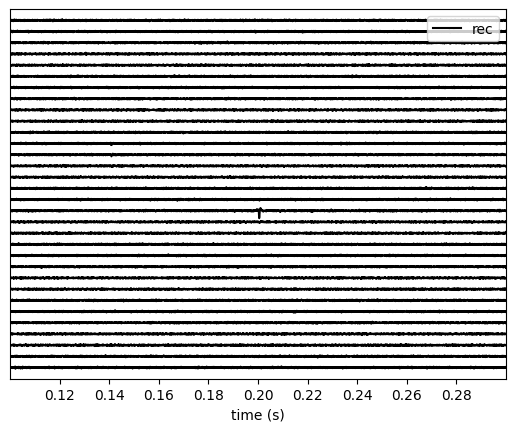

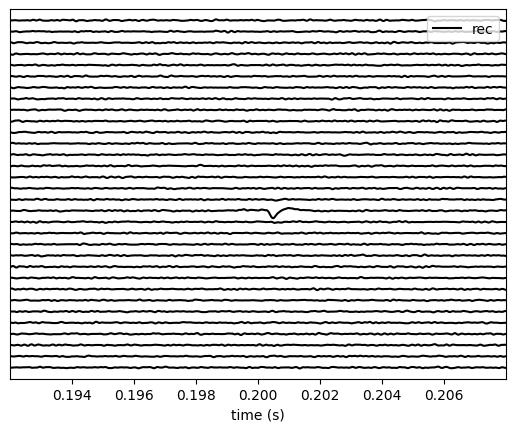

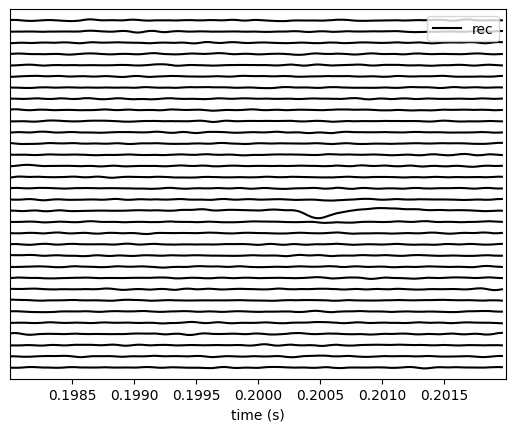

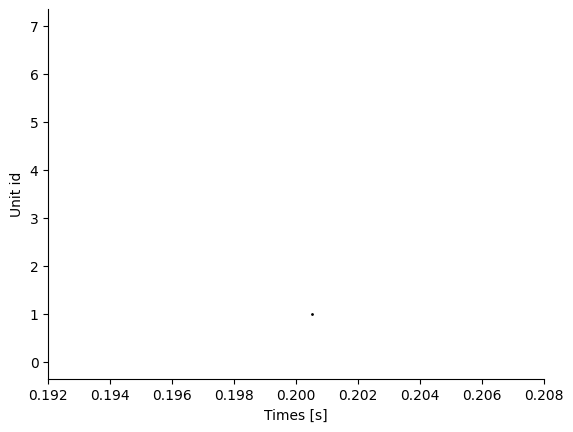

In [16]:
import spikeinterface.widgets as sw
print("Ground Truth Summary:")
for uid in sorting_gt.get_unit_ids():
    spikes = sorting_gt.get_unit_spike_train(uid, segment_index=0)
    print(uid, spikes.size)
w_ts = sw.plot_traces(recording, time_range=(0.1,0.3), segment_index=0)

w_ts = sw.plot_traces(recording, time_range=(0.192,0.208), segment_index=0)
w_ts = sw.plot_traces(recording, time_range=(0.198,0.202), segment_index=0)

w_rs = sw.plot_rasters(sorting_gt, time_range=(0.192, 0.208), segment_index=0)


In [17]:
import pandas as pd
import numpy as np

# =========================================================
# 生成完整的数据集: 每个 spike -> PCA 指纹 + neuron id
# =========================================================
all_spike_bits = []
all_spike_ids = []

for unit in unit_ids:
    st = sorting_gt.get_unit_spike_train(unit_id=unit, segment_index=0)
    
    # 提取波形
    wfs = get_waveforms_from_spikes(st, max_n=None)  # 全部波形
    if len(wfs) == 0:
        continue
    
    # PCA 编码成二值指纹
    bits = encode_waveforms(wfs)  # shape: (num_spikes, 8)
    
    # 存储
    all_spike_bits.append(bits)
    all_spike_ids.extend([unit] * len(bits))

# 堆叠所有 spikes
all_spike_bits = np.vstack(all_spike_bits)  # shape: (总脉冲数, 8)
all_spike_ids = np.array(all_spike_ids)

print(f"总脉冲数: {all_spike_bits.shape[0]}")

# =========================================================
# 构建 DataFrame 保存
# =========================================================
df = pd.DataFrame(all_spike_bits, columns=[f"bit{i}" for i in range(all_spike_bits.shape[1])])
df['unit_id'] = all_spike_ids

print(df.head())

# =========================================================
# 可选: 保存到 CSV
# =========================================================
df.to_csv("spike_pca_dataset.csv", index=False)
print("数据集已保存为 spike_pca_dataset.csv")

总脉冲数: 47987
   bit0  bit1  bit2  bit3  bit4  bit5  bit6  bit7  bit8  bit9  ...  bit23  \
0     1     0     1     0     1     1     0     0     0     0  ...      1   
1     1     0     1     0     1     1     0     1     0     0  ...      1   
2     1     0     1     0     0     0     0     0     1     0  ...      0   
3     1     0     1     0     1     0     0     1     0     0  ...      1   
4     1     0     1     0     0     1     0     0     0     1  ...      1   

   bit24  bit25  bit26  bit27  bit28  bit29  bit30  bit31  unit_id  
0      0      0      0      1      0      0      1      1        0  
1      0      0      1      0      0      1      1      1        0  
2      1      0      0      0      0      0      0      0        0  
3      1      1      1      1      0      0      1      0        0  
4      1      1      1      1      0      1      1      0        0  

[5 rows x 33 columns]
数据集已保存为 spike_pca_dataset.csv


In [18]:
import pandas as pd

# ===============================
# 1. 读取数据集
# ===============================
df = pd.read_csv("spike_pca_dataset.csv")

# 统计 neuron id
unit_ids = df['unit_id'].unique()

# ===============================
# 2. 对每个 neuron 统计指纹组合频率
# ===============================
fingerprint_stats = {}

for unit in unit_ids:
    df_unit = df[df['unit_id'] == unit]
    
    # 取 bit 列
    bit_cols = [f"bit{i}" for i in range(8)]
    
    # 将每一行的 bits 拼成字符串（方便统计组合）
    fingerprints = df_unit[bit_cols].astype(str).agg(''.join, axis=1)
    
    # 统计每种组合出现次数
    counts = fingerprints.value_counts()
    
    # 计算频率
    freqs = counts / counts.sum()
    
    # 保存
    fingerprint_stats[unit] = pd.DataFrame({
        'fingerprint': counts.index,
        'count': counts.values,
        'frequency': freqs.values
    })

# ===============================
# 3. 输出示例
# ===============================
for unit, stats in fingerprint_stats.items():
    print(f"\n=== Unit {unit} ===")
    print(stats.head)  # 打印前10个最常见组合

# ===============================
# 4. 可选: 保存到文件
# ===============================
for unit, stats in fingerprint_stats.items():
    stats.to_csv(f"unit_{unit}_fingerprint_stats.csv", index=False)


=== Unit 0 ===
<bound method NDFrame.head of    fingerprint  count  frequency
0     10100000    471   0.077226
1     10100001    447   0.073291
2     10101010    443   0.072635
3     10100010    439   0.071979
4     10101000    430   0.070503
5     10101011    419   0.068700
6     10101001    415   0.068044
7     10100011    399   0.065421
8     10101110    346   0.056731
9     10101100    344   0.056403
10    10100100    335   0.054927
11    10100110    332   0.054435
12    10101111    324   0.053123
13    10100111    312   0.051156
14    10101101    310   0.050828
15    10100101    294   0.048205
16    10000010      6   0.000984
17    10110100      5   0.000820
18    10111101      5   0.000820
19    10110000      4   0.000656
20    10111111      2   0.000328
21    10001000      2   0.000328
22    10110111      2   0.000328
23    00101011      2   0.000328
24    10111001      2   0.000328
25    00100010      1   0.000164
26    10110011      1   0.000164
27    10111110      1   0.0001

In [19]:
import numpy as np

np.savez(
    "reference_fingerprints_8bit.npz",
    **{f"unit_{k}": v.astype(np.uint8) for k, v in reference_fingerprints.items()}
)

📂 实验目录已创建: spike_experiments/experiment_001_u8_bits32_2000s

[Step 1] 生成并预处理 SpikeInterface 数据...
   - 采样率: 30000.0 Hz
   - 窗口大小: pre=15, post=30 (frames)
   - 训练/测试分割点: frame 30000000

[Step 2] 收集波形并训练 PCA...
   - PCA 训练集形状: (23891, 360)
   - PCA 解释方差比: 0.8976
   - 模型已保存: spike_experiments/experiment_001_u8_bits32_2000s/pca_model.joblib

[Step 3] 生成全量数据集与标准模板...
   - 数据集已保存: spike_experiments/experiment_001_u8_bits32_2000s/spike_pca_dataset.csv (Samples: 47987)
   - 模板已保存: spike_experiments/experiment_001_u8_bits32_2000s/templates.csv


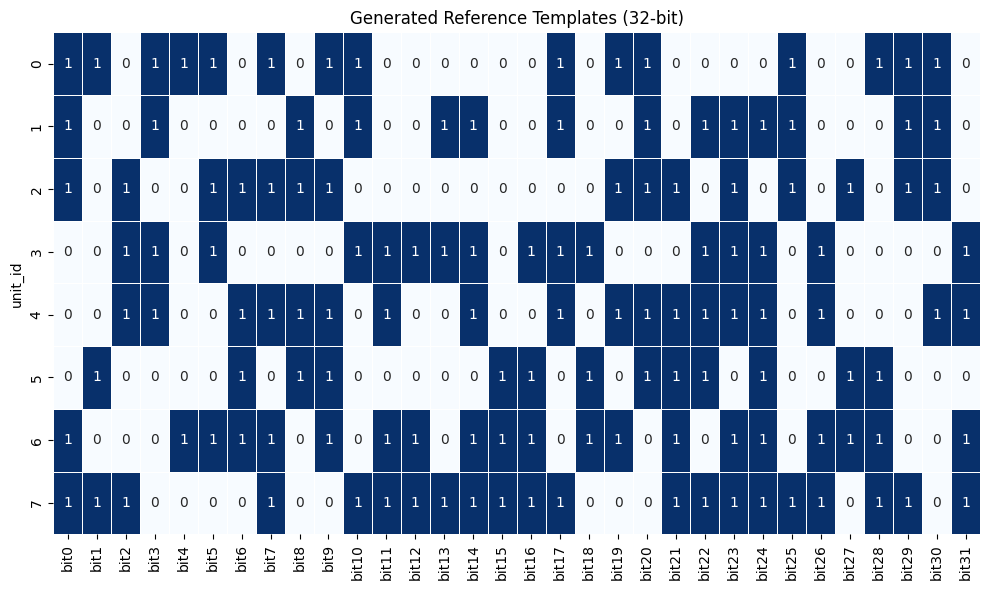


✅ 流水线运行结束！所有文件已保存。


In [21]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass, asdict

# 尝试导入 spikeinterface，如果环境没有则提示
try:
    import spikeinterface.full as si
    from sklearn.decomposition import PCA
except ImportError as e:
    raise ImportError("请确保安装了 spikeinterface 和 scikit-learn: pip install spikeinterface scikit-learn") from e

# =========================================================
# 1. 配置类 (Configuration)
# =========================================================
@dataclass
class PipelineConfig:
    """
    实验参数配置类
    """
    # --- 核心参数 ---
    experiment_name: str = "experiment_001"
    output_base_dir: str = "spike_experiments"
    
    num_units: int = 8          # 神经元数量
    duration: int = 2000        # 数据时长 (秒)
    num_channels: int = 8      # 通道数
    sampling_frequency: float = 30000.0 # 默认采样率 (toy_example 通常是 30k)
    
    # --- 算法参数 ---
    pca_components: int = 32     # [关键] 指纹长度 (Bit Width)
    train_ratio: float = 0.5    # 前多少比例的数据用于训练 PCA 和 提取模板
    waveform_window_ms: float = 1.5 # 截取波形的总长度 (ms)
    pre_window_ms: float = 0.5      # 峰值前长度 (ms)
    
    # --- 采样限制 (内存优化) ---
    max_pca_samples: int = 50000  # 用于训练 PCA 的最大波形数
    max_ref_samples: int = 50000  # 用于计算标准模板的最大波形数
    
    seed: int = 42

    @property
    def save_dir(self):
        """生成带参数的保存路径"""
        folder_name = f"{self.experiment_name}_u{self.num_units}_bits{self.pca_components}_{self.duration}s"
        return os.path.join(self.output_base_dir, folder_name)

# =========================================================
# 2. 核心流水线类 (Pipeline)
# =========================================================
class SpikeInterfacePipeline:
    def __init__(self, config: PipelineConfig):
        self.cfg = config
        self.pca_model = None
        self.recording = None
        self.sorting_gt = None
        
        # 计算采样点数
        # 注意：这里假设 toy_example 默认 30kHz，实际会从 recording 获取
        self.n_pre = None 
        self.n_post = None
        self.split_frame = None
        
        # 创建输出目录
        os.makedirs(self.cfg.save_dir, exist_ok=True)
        print(f"📂 实验目录已创建: {self.cfg.save_dir}")
        self._save_config()

    def _save_config(self):
        config_path = os.path.join(self.cfg.save_dir, "config.json")
        with open(config_path, 'w') as f:
            json.dump(asdict(self.cfg), f, indent=4)

    def run(self):
        """执行完整流水线"""
        # 1. 数据生成与预处理
        self.step_1_generate_and_preprocess()
        
        # 2. 训练 PCA
        self.step_2_train_pca()
        
        # 3. 生成数据集与模板
        self.step_3_create_dataset_and_templates()
        
        print("\n✅ 流水线运行结束！所有文件已保存。")

    # -----------------------------------------------------
    # Step 1: 数据准备
    # -----------------------------------------------------
    def step_1_generate_and_preprocess(self):
        print("\n[Step 1] 生成并预处理 SpikeInterface 数据...")
        
        # A. 生成数据
        self.recording, self.sorting_gt = si.toy_example(
            duration=self.cfg.duration,
            num_channels=self.cfg.num_channels,
            num_units=self.cfg.num_units,
            seed=self.cfg.seed
        )
        
        # B. 预处理: 滤波 + CMR
        self.recording = si.bandpass_filter(self.recording, freq_min=300, freq_max=6000)
        self.recording = si.common_reference(self.recording, reference="global", operator="median")
        
        # C. 更新参数
        fs = self.recording.get_sampling_frequency()
        self.n_pre = int(self.cfg.pre_window_ms * fs / 1000)
        self.n_post = int((self.cfg.waveform_window_ms - self.cfg.pre_window_ms) * fs / 1000)
        self.split_frame = int(self.cfg.duration * self.cfg.train_ratio * fs)
        
        print(f"   - 采样率: {fs} Hz")
        print(f"   - 窗口大小: pre={self.n_pre}, post={self.n_post} (frames)")
        print(f"   - 训练/测试分割点: frame {self.split_frame}")

    # -----------------------------------------------------
    # 辅助: 波形提取
    # -----------------------------------------------------
    def _get_waveforms(self, spikes_frames, max_n=None):
        """从 Recording 中提取波形"""
        if max_n and len(spikes_frames) > max_n:
            indices = np.random.choice(len(spikes_frames), max_n, replace=False)
            spikes_frames = spikes_frames[indices]
        
        wfs = []
        num_frames = self.recording.get_num_frames(segment_index=0)
        
        # 批量获取可能会更快，但为了代码清晰，这里沿用你的逻辑
        # 实际生产中建议使用 spikeinterface 的 WaveformExtractor
        for t in spikes_frames:
            if t - self.n_pre < 0 or t + self.n_post > num_frames:
                continue
            wf = self.recording.get_traces(
                segment_index=0, 
                start_frame=t - self.n_pre, 
                end_frame=t + self.n_post
            ).flatten() # 展平: (channels * timepoints)
            wfs.append(wf)
        
        return np.array(wfs)

    # -----------------------------------------------------
    # Step 2: 训练 PCA
    # -----------------------------------------------------
    def step_2_train_pca(self):
        print("\n[Step 2] 收集波形并训练 PCA...")
        unit_ids = self.sorting_gt.get_unit_ids()
        all_train_wfs = []
        
        # 平均分配每个 Unit 的采样配额
        samples_per_unit = self.cfg.max_pca_samples // len(unit_ids)
        
        for unit in unit_ids:
            st = self.sorting_gt.get_unit_spike_train(unit_id=unit, segment_index=0)
            # 只取训练段的数据
            st_train = st[st < self.split_frame]
            
            wfs = self._get_waveforms(st_train, max_n=samples_per_unit)
            if len(wfs) > 0:
                all_train_wfs.append(wfs)
        
        if not all_train_wfs:
            raise ValueError("没有提取到任何训练波形，请检查 duration 或 train_ratio")

        all_train_wfs = np.vstack(all_train_wfs)
        print(f"   - PCA 训练集形状: {all_train_wfs.shape}")
        
        # 训练
        self.pca_model = PCA(n_components=self.cfg.pca_components)
        self.pca_model.fit(all_train_wfs)
        
        explained_var = np.sum(self.pca_model.explained_variance_ratio_)
        print(f"   - PCA 解释方差比: {explained_var:.4f}")
        
        # 保存模型
        model_path = os.path.join(self.cfg.save_dir, "pca_model.joblib")
        joblib.dump(self.pca_model, model_path)
        print(f"   - 模型已保存: {model_path}")

    def _encode(self, wfs):
        if len(wfs) == 0: return np.array([])
        feats = self.pca_model.transform(wfs)
        return (feats > 0).astype(int)

    # -----------------------------------------------------
    # Step 3: 生成数据集与模板
    # -----------------------------------------------------
    def step_3_create_dataset_and_templates(self):
        print("\n[Step 3] 生成全量数据集与标准模板...")
        unit_ids = self.sorting_gt.get_unit_ids()
        
        all_spike_bits = []
        all_spike_ids = []
        templates_dict = {}
        
        for unit in unit_ids:
            st = self.sorting_gt.get_unit_spike_train(unit_id=unit, segment_index=0)
            
            # --- 1. 计算模板 (仅用训练集) ---
            st_train = st[st < self.split_frame]
            wfs_ref = self._get_waveforms(st_train, max_n=self.cfg.max_ref_samples)
            
            if len(wfs_ref) > 0:
                bits_ref = self._encode(wfs_ref)
                # Majority Vote
                ref_template = (np.mean(bits_ref, axis=0) > 0.5).astype(int)
                templates_dict[int(unit)] = ref_template.tolist()
            
            # --- 2. 生成数据集 (使用全部数据) ---
            # 如果想只保存测试集，可以改这里
            wfs_all = self._get_waveforms(st, max_n=None) 
            if len(wfs_all) > 0:
                bits_all = self._encode(wfs_all)
                all_spike_bits.append(bits_all)
                all_spike_ids.extend([unit] * len(bits_all))
                
        # 保存数据集 CSV
        if all_spike_bits:
            all_spike_bits = np.vstack(all_spike_bits)
            cols = [f"bit{i}" for i in range(self.cfg.pca_components)]
            df = pd.DataFrame(all_spike_bits, columns=cols)
            df['unit_id'] = all_spike_ids
            
            csv_path = os.path.join(self.cfg.save_dir, "spike_pca_dataset.csv")
            df.to_csv(csv_path, index=False)
            print(f"   - 数据集已保存: {csv_path} (Samples: {len(df)})")
            
        # 保存模板 CSV 和 JSON
        if templates_dict:
            # CSV 格式
            temp_rows = []
            for uid, bits in templates_dict.items():
                row = {"unit_id": uid}
                for i, b in enumerate(bits):
                    row[f"bit{i}"] = b
                temp_rows.append(row)
            df_temp = pd.DataFrame(temp_rows)
            temp_csv_path = os.path.join(self.cfg.save_dir, "templates.csv")
            df_temp.to_csv(temp_csv_path, index=False)
            
            # JSON 格式 (方便读取)
            temp_json_path = os.path.join(self.cfg.save_dir, "templates.json")
            with open(temp_json_path, 'w') as f:
                json.dump(templates_dict, f)
            print(f"   - 模板已保存: {temp_csv_path}")

        # 可视化一下模板
        self._plot_templates(df_temp)

    def _plot_templates(self, df_templates):
        plt.figure(figsize=(10, len(df_templates)*0.5 + 2))
        bit_cols = [c for c in df_templates.columns if 'bit' in c]
        sns.heatmap(df_templates[bit_cols].set_index(df_templates['unit_id']),
                    annot=True, cmap="Blues", cbar=False, linewidths=0.5)
        plt.title(f"Generated Reference Templates ({self.cfg.pca_components}-bit)")
        plt.tight_layout()
        plt.savefig(os.path.join(self.cfg.save_dir, "templates_vis.png"))
        plt.show()

# =========================================================
# 3. 主程序入口
# =========================================================
if __name__ == "__main__":
    # --- 你只需要修改这里的参数 ---
    config = PipelineConfig()
    
    # 启动流水线
    pipeline = SpikeInterfacePipeline(config)
    pipeline.run()